In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load & Sample
df = pd.read_csv("Data/Reviews.csv")
df = df.sample(n=40000, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(df.columns.tolist())

Shape: (40000, 10)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


Score
1     3623
2     2077
3     3016
4     5656
5    25628
Name: count, dtype: int64


C:\Users\arahm\AppData\Local\Temp\ipykernel_8476\3755627172.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='Blues_d')


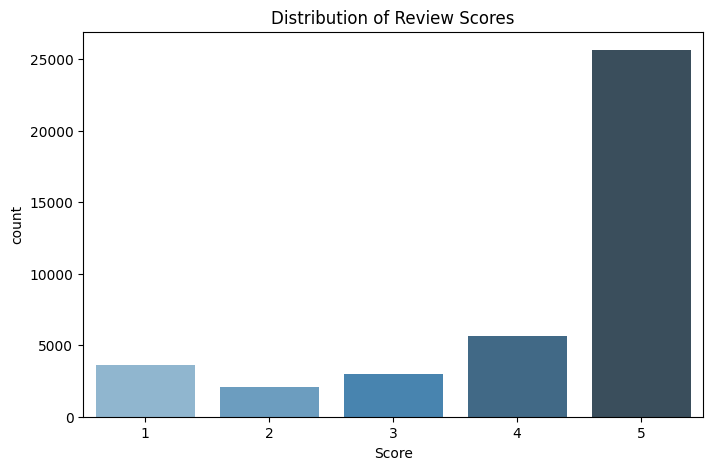

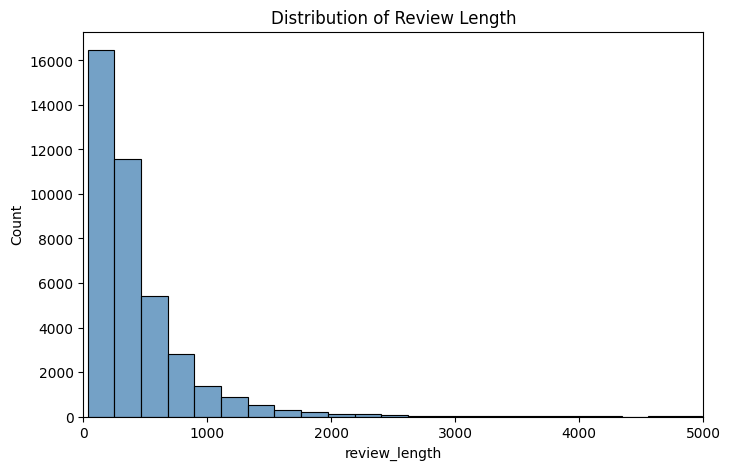

In [ ]:
print(df['Score'].value_counts().sort_index())

df['review_length'] = df['Text'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.countplot(x='Score', data=df, palette='Blues_d')
plt.title('Distribution of Review Scores')
plt.savefig('Images/score_distribution.png')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['review_length'], bins=50, color='steelblue')
plt.title('Distribution of Review Length')
plt.xlim(0, 5000)
plt.savefig('Images/review_length.png')
plt.show()

In [4]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

print("Cleaning text... (this may take 1-2 minutes)")
df['cleaned_text'] = df['Text'].apply(clean_text)
print("Done!")

print("\nOriginal:", df['Text'][0])
print("\nCleaned:", df['cleaned_text'][0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arahm\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Cleaning text... (this may take 1-2 minutes)
Done!

Original: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I've satisfied my sweet tooth sooner!  The chocolate version from Glutino is just as good and has a true "chocolatey" taste - something that isn't there with the other gluten-free brands out there.

Cleaned: tried couple brands glutenfree sandwich cookies best bunch theyre crunchy true texture real cookies arent glutenfree might think filling makes bit sweet means ive satisfied sweet tooth sooner chocolate version glutino good true chocolatey taste something isnt glutenfree brands


In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score['compound']
    
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def get_compound_score(text):
    return analyzer.polarity_scores(text)['compound']

print("Running sentiment analysis... (this may take 2-3 minutes)")
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)
df['compound_score'] = df['cleaned_text'].apply(get_compound_score)

print("Done!")
print("\n=== SENTIMENT DISTRIBUTION ===")
print(df['sentiment'].value_counts())

Running sentiment analysis... (this may take 2-3 minutes)
Done!

=== SENTIMENT DISTRIBUTION ===
sentiment
Positive    36024
Negative     3107
Neutral       869
Name: count, dtype: int64


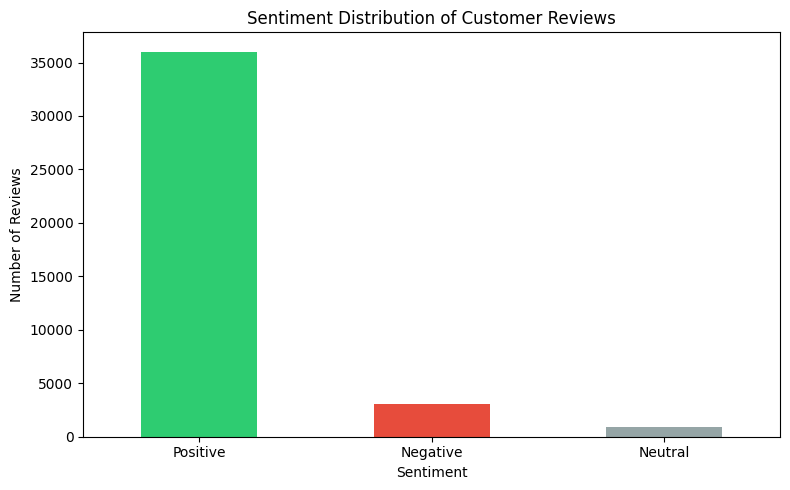

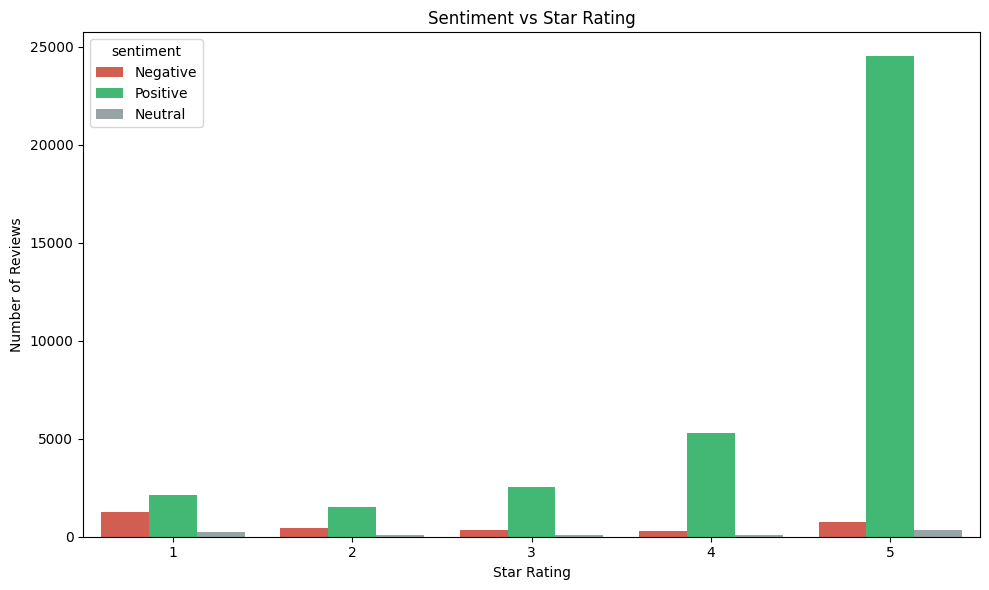

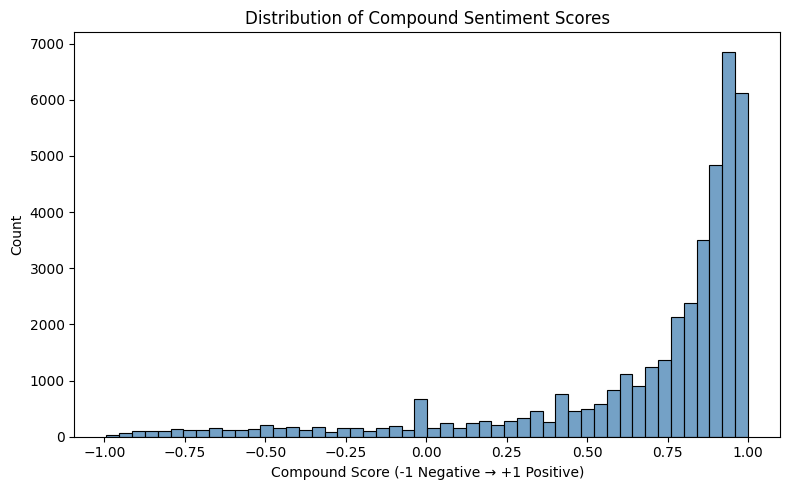

In [ ]:
# ============================================
# STEP 5: VISUALIZATIONS
# ============================================

# ---- PLOT 1: Sentiment Distribution ----
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
df['sentiment'].value_counts().plot(kind='bar', color=colors)
plt.title('Sentiment Distribution of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Images/sentiment_distribution.png')
plt.show()

# ---- PLOT 2: Sentiment vs Star Rating ----
plt.figure(figsize=(10, 6))
sns.countplot(x='Score', hue='sentiment', data=df, 
              palette={'Positive':'#2ecc71', 
                       'Negative':'#e74c3c', 
                       'Neutral':'#95a5a6'})
plt.title('Sentiment vs Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('Images/sentiment_vs_rating.png')
plt.show()

# ---- PLOT 3: Compound Score Distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(df['compound_score'], bins=50, color='steelblue')
plt.title('Distribution of Compound Sentiment Scores')
plt.xlabel('Compound Score (-1 Negative → +1 Positive)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Images/compound_scores.png')
plt.show()

In [8]:
# ============================================
# STEP 6: TOPIC CLASSIFICATION
# ============================================

# Define keywords for each topic
topics = {
    'Delivery & Shipping': ['delivery', 'shipping', 'arrived', 'package', 
                             'days', 'late', 'fast', 'slow'],
    'Product Quality':     ['quality', 'fresh', 'good', 'bad', 'excellent',
                             'poor', 'perfect', 'broken', 'damaged'],
    'Price & Value':       ['price', 'expensive', 'cheap', 'value', 'worth',
                             'money', 'cost', 'affordable'],
    'Taste & Flavor':      ['taste', 'flavor', 'delicious', 'disgusting',
                             'sweet', 'sour', 'bland', 'yummy'],
    'Packaging':           ['packaging', 'box', 'bag', 'container', 
                             'sealed', 'wrap', 'opened']
}

def classify_topic(text):
    text = str(text).lower()
    for topic, keywords in topics.items():
        for word in keywords:
            if word in text:
                return topic
    return 'Other'

print("Classifying topics...")
df['topic'] = df['cleaned_text'].apply(classify_topic)

print("Done!")
print("\n=== TOPIC DISTRIBUTION ===")
print(df['topic'].value_counts())

Classifying topics...
Done!

=== TOPIC DISTRIBUTION ===
topic
Product Quality        12425
Delivery & Shipping    10306
Taste & Flavor          6877
Other                   5839
Price & Value           3522
Packaging               1031
Name: count, dtype: int64


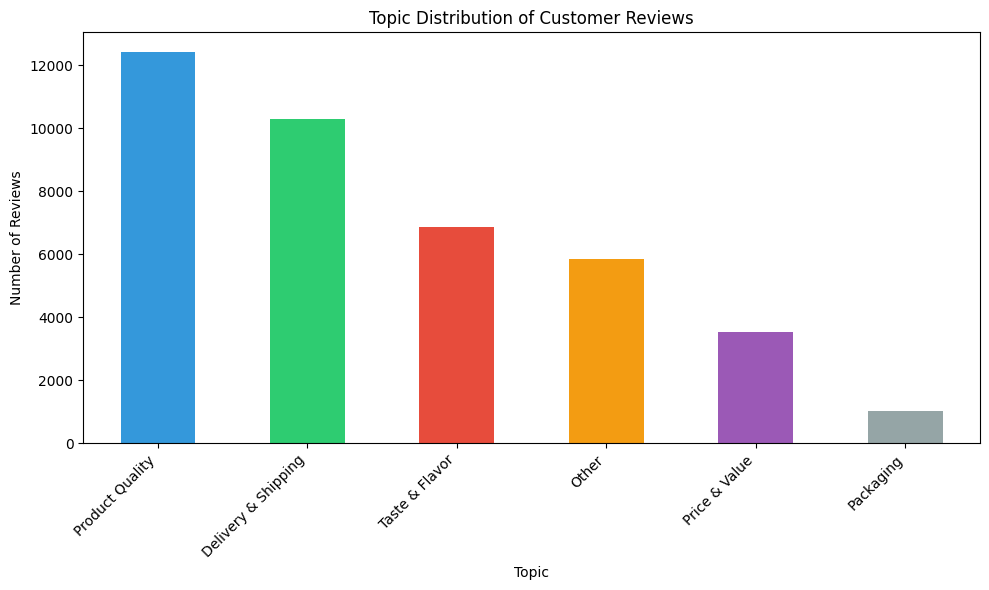

<Figure size 1200x600 with 0 Axes>

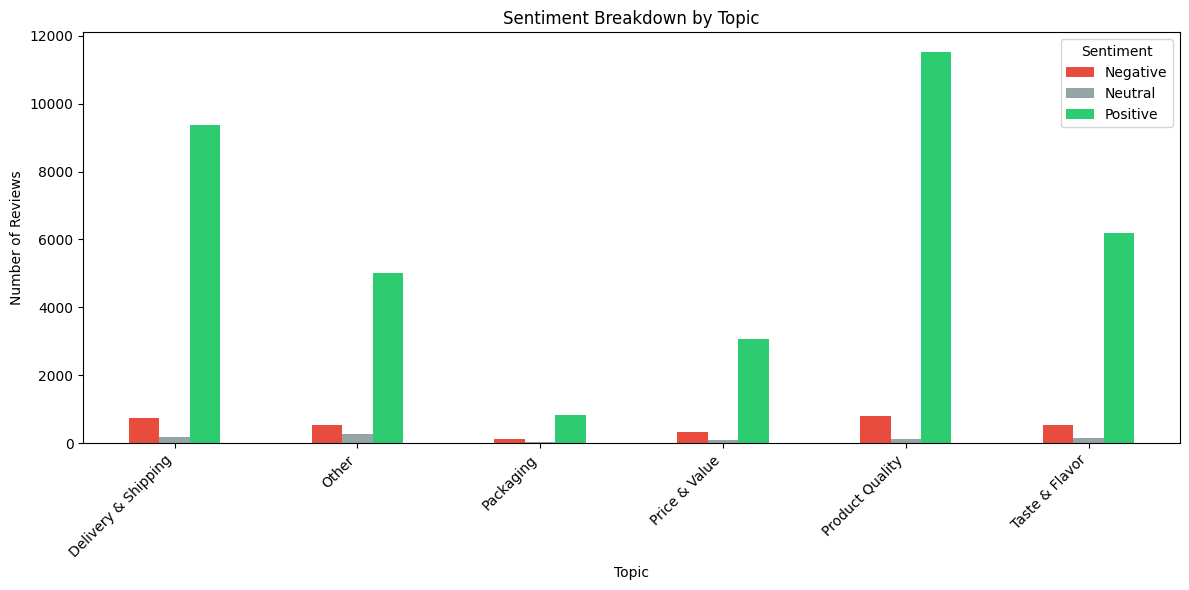

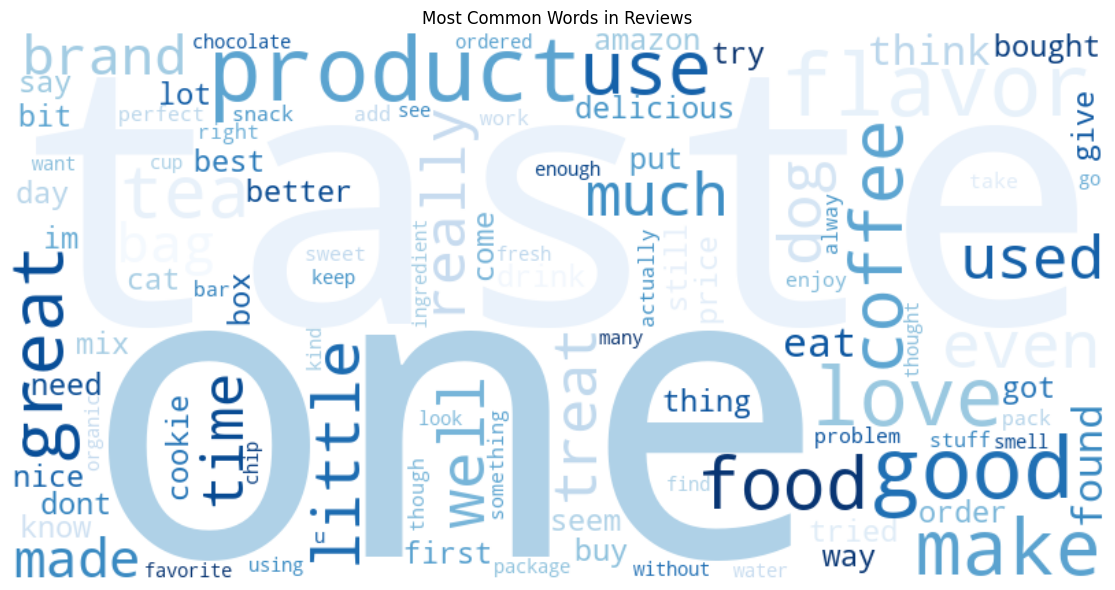

In [ ]:
# ---- PLOT 1: Topic Distribution ----
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', 
          '#f39c12', '#9b59b6', '#95a5a6']
df['topic'].value_counts().plot(kind='bar', color=colors)
plt.title('Topic Distribution of Customer Reviews')
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Images/topic_distribution.png')
plt.show()

# ---- PLOT 2: Sentiment by Topic ----
plt.figure(figsize=(12, 6))
topic_sentiment = df.groupby(['topic', 'sentiment']).size().unstack()
topic_sentiment.plot(kind='bar', 
                     color=['#e74c3c', '#95a5a6', '#2ecc71'],
                     figsize=(12, 6))
plt.title('Sentiment Breakdown by Topic')
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('Images/sentiment_by_topic.png')
plt.show()

# ---- PLOT 3: Wordcloud ----
from wordcloud import WordCloud

text_all = ' '.join(df['cleaned_text'].tolist())
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='Blues',
                      max_words=100).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.tight_layout()
plt.savefig('Images/wordcloud.png')
plt.show()

In [10]:
# ============================================
# STEP 7: BUSINESS INSIGHTS SUMMARY
# ============================================

print("=" * 50)
print("   CUSTOMER REVIEW ANALYSIS - KEY FINDINGS")
print("=" * 50)

# 1. Overall sentiment
total = len(df)
positive_pct = round(df['sentiment'].value_counts()['Positive'] / total * 100, 1)
negative_pct = round(df['sentiment'].value_counts()['Negative'] / total * 100, 1)
neutral_pct = round(df['sentiment'].value_counts()['Neutral'] / total * 100, 1)

print(f"\n📊 SENTIMENT ANALYSIS ({total:,} reviews)")
print(f"   ✅ Positive : {positive_pct}%")
print(f"   ❌ Negative : {negative_pct}%")
print(f"   ➖ Neutral  : {neutral_pct}%")

# 2. Top topic
top_topic = df['topic'].value_counts().index[0]
top_topic_pct = round(df['topic'].value_counts().iloc[0] / total * 100, 1)

print(f"\n🔍 TOPIC CLASSIFICATION")
print(f"   Most discussed topic : {top_topic} ({top_topic_pct}%)")
for topic, count in df['topic'].value_counts().items():
    pct = round(count / total * 100, 1)
    print(f"   {topic:30s}: {pct}%")

# 3. Negative reviews by topic
print(f"\n⚠️  NEGATIVE REVIEWS BY TOPIC")
negative_df = df[df['sentiment'] == 'Negative']
for topic, count in negative_df['topic'].value_counts().items():
    pct = round(count / len(negative_df) * 100, 1)
    print(f"   {topic:30s}: {pct}% of all negative reviews")

# 4. Average sentiment score by topic
print(f"\n📈 AVERAGE SENTIMENT SCORE BY TOPIC")
avg_scores = df.groupby('topic')['compound_score'].mean().sort_values()
for topic, score in avg_scores.items():
    bar = "🟢" if score > 0.3 else "🟡" if score > 0 else "🔴"
    print(f"   {bar} {topic:30s}: {score:.3f}")

print("\n" + "=" * 50)
print("✅ Analysis Complete!")
print("=" * 50)

   CUSTOMER REVIEW ANALYSIS - KEY FINDINGS

📊 SENTIMENT ANALYSIS (40,000 reviews)
   ✅ Positive : 90.1%
   ❌ Negative : 7.8%
   ➖ Neutral  : 2.2%

🔍 TOPIC CLASSIFICATION
   Most discussed topic : Product Quality (31.1%)
   Product Quality               : 31.1%
   Delivery & Shipping           : 25.8%
   Taste & Flavor                : 17.2%
   Other                         : 14.6%
   Price & Value                 : 8.8%
   Packaging                     : 2.6%

⚠️  NEGATIVE REVIEWS BY TOPIC
   Product Quality               : 25.5% of all negative reviews
   Delivery & Shipping           : 24.4% of all negative reviews
   Other                         : 17.4% of all negative reviews
   Taste & Flavor                : 17.2% of all negative reviews
   Price & Value                 : 11.1% of all negative reviews
   Packaging                     : 4.4% of all negative reviews

📈 AVERAGE SENTIMENT SCORE BY TOPIC
   🟢 Packaging                     : 0.534
   🟢 Other                         : 

In [ ]:
# ============================================
# SAVE RESULTS FOR STREAMLIT DASHBOARD
# ============================================

# Save the analyzed dataframe
df.to_csv('Data/analyzed_reviews.csv', index=False)
print("✅ Data saved to analyzed_reviews.csv")

# Check file was saved correctly
test = pd.read_csv('analyzed_reviews.csv')
print(f"✅ Verified: {test.shape[0]:,} rows saved")
print(f"✅ Columns: {test.columns.tolist()}")

✅ Data saved to analyzed_reviews.csv
✅ Verified: 40,000 rows saved
✅ Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'cleaned_text', 'sentiment', 'compound_score', 'topic']
